# Analysis of Nutrition, Physical Activity, and Obesity Trends in the United States

**Dataset:** CDC Behavioral Risk Factor Surveillance System (BRFSS)  
**Source:** U.S. Centers for Disease Control and Prevention — data.cdc.gov  
**Period Covered:** 2011–2024  
**Total Records:** 110,880 observations across 33 variables  

---

## Project Overview

This notebook investigates obesity prevalence across the United States using the CDC BRFSS survey dataset. The dataset captures annual, state-level self-reported health behaviour data, covering three major domains:

- **Obesity / Weight Status** — percentage of adults classified as obese (BMI ≥ 30)
- **Physical Activity** — aerobic and muscle-strengthening activity levels, including leisure-time inactivity
- **Fruits and Vegetables** — frequency of fruit and vegetable consumption

Each record is stratified by demographic group (Sex, Age, Race/Ethnicity, Income, Education), enabling multidimensional analysis of health disparities.

### Dataset Limitations & Considerations

1. **Self-reported data** — All values come from telephone surveys. Respondents may underreport obesity or overreport healthy behaviours (social desirability bias).
2. **Missing values (≈11.9%)** — `Data_Value` is missing for 13,214 rows. These correspond to suppressed cells where sample sizes were too small to report reliably (as noted in `Data_Value_Footnote`). Rows with missing `Data_Value` are dropped for numeric analysis.
3. **Stratification overlap** — The same state-year combination appears once per demographic stratification. To avoid double-counting when computing national averages, we filter to `StratificationCategory1 == 'Total'`.
4. **Aggregate percentages, not individual-level data** — This dataset does not contain individual respondent records. All `Data_Value` figures are pre-aggregated survey percentages, limiting the types of statistical modelling that can be applied.
5. **Geographic scope** — Includes all 50 U.S. states plus DC, territories (Guam, Puerto Rico, Virgin Islands), and national aggregates. Where state-level analysis is intended, non-state entities are retained unless otherwise noted.

---

## Analyses Performed

| # | Analysis | Purpose |
|---|----------|---------|
| 1 | Data Loading, Cleaning & EDA | Understand structure, quality, and key statistics |
| 2 | Obesity Trend Over Time (2011–2024) | Detect national trajectory |
| 3 | State-wise Obesity Comparison | Identify highest and lowest burden states |
| 4 | Physical Inactivity vs Obesity (Correlation) | Quantify the activity–obesity relationship |
| 5 | Obesity by Gender | Assess sex-based disparities |
| 6 | Obesity by Age Group | Understand life-stage vulnerability |
| 7 | Obesity by Race/Ethnicity | Surface racial health disparities |
| 8 | Obesity by Income Level | Examine socioeconomic gradient |
| 9 | Obesity by Education Level | Investigate educational attainment link |
| 10 | Poor Nutrition vs Obesity (Scatter + Regression) | Explore diet-obesity association |

---
# Section 1: Setup — Import Libraries & Configure Display

In [31]:
# ─── Standard Library Imports ───────────────────────────────────────────────
import pandas as pd          # Data manipulation and aggregation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Base plotting framework
import seaborn as sns        # Statistical visualisation on top of matplotlib
from scipy import stats      # Statistical tests (Pearson correlation, etc.)
import warnings
warnings.filterwarnings('ignore')  # Suppress minor deprecation warnings for clean output

# ─── Global Display & Style Settings ────────────────────────────────────────
pd.set_option('display.max_columns', None)   # Show all columns in dataframe previews
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places for floats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
# 'whitegrid' gives clean axes; font_scale=1.1 improves readability in reports

FIGURE_SIZE_WIDE  = (12, 6)   # Standard widescreen chart size
FIGURE_SIZE_TALL  = (10, 8)   # For charts with many categories on y-axis
FIGURE_SIZE_SMALL = (8, 5)    # For simple 2-category comparisons

print("Libraries loaded and display settings configured.")

Libraries loaded and display settings configured.


---
# Section 2: Data Loading & Initial Inspection

In [32]:
# ─── Load Dataset ────────────────────────────────────────────────────────────
# low_memory=False suppresses dtype inference warnings for mixed-type columns
# (e.g. Data_Value_Unit contains both numeric strings and empty cells)
FILE_PATH = "Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv"

df = pd.read_csv(FILE_PATH, low_memory=False)

print(f"Dataset loaded successfully!")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Years   : {df['YearStart'].min()} – {df['YearStart'].max()}")
print(f"  States  : {df['LocationDesc'].nunique()} unique locations")

# Preview first 5 rows
df.head()

Dataset loaded successfully!
  Rows    : 110,880
  Columns : 33
  Years   : 2011 – 2024
  States  : 55 unique locations


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Alt,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,Total,Age(years),Education,Sex,Income,Race/Ethnicity,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,34.80,34.80,NaN,NaN,31.30,38.50,1367.00,NaN,NaN,NaN,NaN,"$15,000 - $24,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,35.80,35.80,NaN,NaN,31.10,40.80,757.00,NaN,NaN,NaN,NaN,"$25,000 - $34,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,32.30,32.30,NaN,NaN,28.00,36.80,861.00,NaN,NaN,NaN,NaN,"$35,000 - $49,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,34.10,34.10,NaN,NaN,29.70,38.80,785.00,NaN,NaN,NaN,NaN,"$50,000 - $74,999",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,28.80,28.80,NaN,NaN,25.40,32.50,1125.00,NaN,NaN,NaN,NaN,"$75,000 or greater",NaN,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


In [33]:
# ─── Column Names & Data Types ───────────────────────────────────────────────
# Understanding each column before cleaning avoids assumptions
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110880 entries, 0 to 110879
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   110880 non-null  int64  
 1   YearEnd                     110880 non-null  int64  
 2   LocationAbbr                110880 non-null  object 
 3   LocationDesc                110880 non-null  object 
 4   Datasource                  110880 non-null  object 
 5   Class                       110880 non-null  object 
 6   Topic                       110880 non-null  object 
 7   Question                    110880 non-null  object 
 8   Data_Value_Unit             4620 non-null    object 
 9   Data_Value_Type             110880 non-null  object 
 10  Data_Value                  97666 non-null   float64
 11  Data_Value_Alt              97666 non-null   float64
 12  Data_Value_Footnote_Symbol  13214 non-null   object 
 13  Data_Value_Foo

In [34]:
# ─── Unique Values in Key Categorical Columns ────────────────────────────────
# These three columns define the analytical dimensions of the dataset

print("=== Class (broad topic areas) ===")
print(df['Class'].unique())

print("\n=== All Question Types ===")
for q in df['Question'].unique():
    print(" •", q)

print("\n=== Stratification Categories ===")
print(df['StratificationCategory1'].unique())

print("\n=== Years Available ===")
print(sorted(df['YearStart'].unique()))

=== Class (broad topic areas) ===
['Obesity / Weight Status' 'Physical Activity' 'Fruits and Vegetables']

=== All Question Types ===
 • Percent of adults aged 18 years and older who have obesity
 • Percent of adults aged 18 years and older who have an overweight classification
 • Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)
 • Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week
 • Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)
 • Percent of adults who engage in musc

---
# Section 3: Data Cleaning

In [35]:
# ─── Step 1: Missing Value Audit ─────────────────────────────────────────────
# Identify which columns have missing data and how severe it is
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Columns with missing values:")
print(missing_report[missing_report['Missing Count'] > 0].to_string())

Columns with missing values:
                            Missing Count  Missing %
Total                              106920      96.43
Data_Value_Unit                    106260      95.83
Sex                                102960      92.86
Data_Value_Footnote                 97666      88.08
Data_Value_Footnote_Symbol          97666      88.08
Education                           95040      85.71
Age(years)                          87120      78.57
Income                              83160      75.00
Race/Ethnicity                      79200      71.43
Low_Confidence_Limit                13214      11.92
Data_Value_Alt                      13214      11.92
Data_Value                          13214      11.92
Sample_Size                         13214      11.92
High_Confidence_Limit               13214      11.92
GeoLocation                          2016       1.82


In [36]:
# ─── Step 2: Why is Data_Value Missing? ──────────────────────────────────────
# Before dropping rows, understand the reason — suppressed cells are common in
# public health surveys when subgroup sample sizes fall below reporting thresholds

missing_footnotes = (
    df[df['Data_Value'].isnull()]['Data_Value_Footnote']
    .value_counts(dropna=False)
)
print("Footnotes for missing Data_Value rows:")
print(missing_footnotes)

# Insight: Most missing values are 'suppressed' due to insufficient sample size.
# These are NOT random — they disproportionately affect smaller subgroups.
# We drop them for analysis but note this may slightly underrepresent
# small or rural demographic groups.

Footnotes for missing Data_Value rows:
Data_Value_Footnote
Data not available because sample size is insufficient or data not reported.    13214
Name: count, dtype: int64


In [37]:
# ─── Step 3: Select & Clean Relevant Columns ─────────────────────────────────
# We retain only the columns needed for analysis.
# Confidence limits are kept for context in uncertainty discussions.

COLS_TO_KEEP = [
    'YearStart',
    'LocationDesc',
    'LocationAbbr',
    'Class',
    'Question',
    'Data_Value',
    'Low_Confidence_Limit',
    'High_Confidence_Limit ',   # Note: trailing space in original column name
    'Sample_Size',
    'StratificationCategory1',
    'Stratification1'
]

df_clean = df[COLS_TO_KEEP].copy()

# Rename the confidence limit column to remove trailing space
df_clean.rename(columns={'High_Confidence_Limit ': 'High_Confidence_Limit'}, inplace=True)

# ─── Step 4: Drop Rows with Missing Data_Value ───────────────────────────────
rows_before = len(df_clean)
df_clean.dropna(subset=['Data_Value'], inplace=True)
rows_after = len(df_clean)

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Rows dropped         : {rows_before - rows_after:,} ({(rows_before-rows_after)/rows_before*100:.1f}%)")

Rows before cleaning : 110,880
Rows after cleaning  : 97,666
Rows dropped         : 13,214 (11.9%)


In [38]:
# ─── Step 5: Enforce Correct Data Types ──────────────────────────────────────
df_clean['YearStart']   = df_clean['YearStart'].astype(int)
df_clean['Data_Value']  = df_clean['Data_Value'].astype(float)
df_clean['Sample_Size'] = pd.to_numeric(df_clean['Sample_Size'], errors='coerce')

# ─── Step 6: Standardise String Columns ──────────────────────────────────────
# Strip leading/trailing whitespace that can cause silent groupby mismatches
str_cols = ['LocationDesc', 'LocationAbbr', 'Class', 'Question',
            'StratificationCategory1', 'Stratification1']
for col in str_cols:
    df_clean[col] = df_clean[col].str.strip()

print("Data types after cleaning:")
print(df_clean.dtypes)
print("\nCleaned dataset shape:", df_clean.shape)
df_clean.head()

Data types after cleaning:
YearStart                    int64
LocationDesc                object
LocationAbbr                object
Class                       object
Question                    object
Data_Value                 float64
Low_Confidence_Limit       float64
High_Confidence_Limit      float64
Sample_Size                float64
StratificationCategory1     object
Stratification1             object
dtype: object

Cleaned dataset shape: (97666, 11)


,YearStart,LocationDesc,LocationAbbr,Class,Question,Data_Value,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,StratificationCategory1,Stratification1
0,2011,Alabama,AL,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,34.80,31.30,38.50,1367.00,Income,"$15,000 - $24,999"
1,2011,Alabama,AL,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,35.80,31.10,40.80,757.00,Income,"$25,000 - $34,999"
2,2011,Alabama,AL,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,32.30,28.00,36.80,861.00,Income,"$35,000 - $49,999"
3,2011,Alabama,AL,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,34.10,29.70,38.80,785.00,Income,"$50,000 - $74,999"
4,2011,Alabama,AL,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,28.80,25.40,32.50,1125.00,Income,"$75,000 or greater"


---
# Section 4: Exploratory Data Analysis (EDA)

Before the targeted analyses, we get a broad statistical feel for the dataset.

In [39]:
# ─── Descriptive Statistics ───────────────────────────────────────────────────
# Summary stats for the core numeric measure
print("Descriptive Statistics for Data_Value (all question types combined):")
print(df_clean['Data_Value'].describe())

print("\nRecord count by Class:")
print(df_clean['Class'].value_counts())

print("\nRecord count by Stratification Category:")
print(df_clean['StratificationCategory1'].value_counts())

Descriptive Statistics for Data_Value (all question types combined):
count   97666.00
mean       31.80
std        10.34
min         0.90
25%        24.90
50%        31.80
75%        37.40
max        85.30
Name: Data_Value, dtype: float64

Record count by Class:
Class
Physical Activity          51355
Obesity / Weight Status    38156
Fruits and Vegetables       8155
Name: count, dtype: int64

Record count by Stratification Category:
StratificationCategory1
Income            26917
Age (years)       23076
Race/Ethnicity    20751
Education         15384
Sex                7692
Total              3846
Name: count, dtype: int64


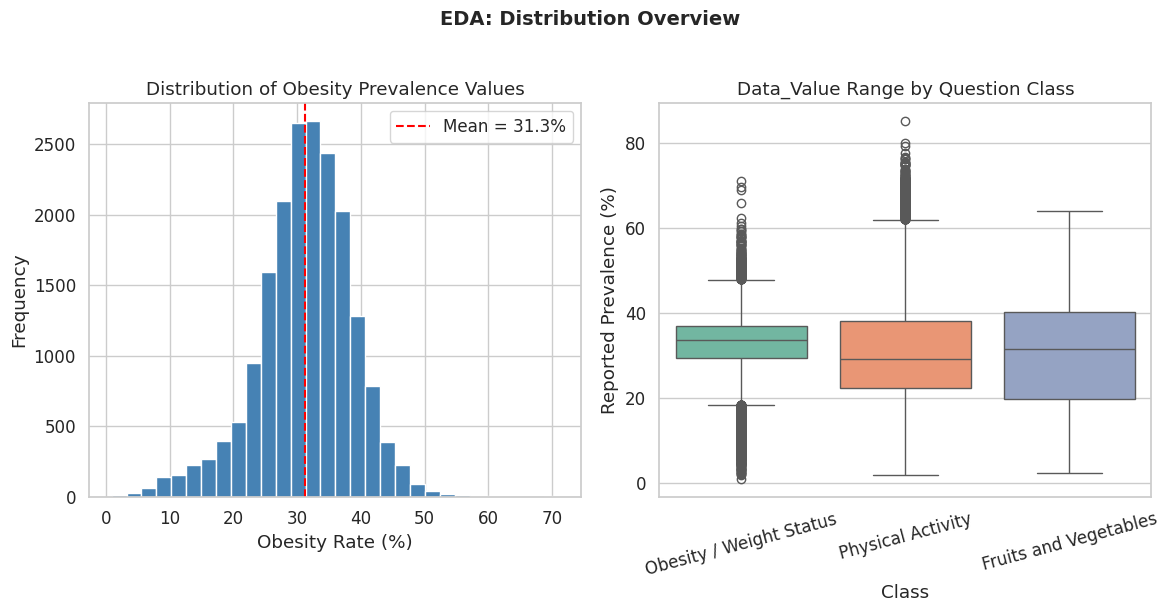


Obesity Data_Value — Mean: 31.27%, Median: 31.70%, Std: 7.45%


In [40]:
# ─── Distribution of Obesity Prevalence Values ────────────────────────────────
# Understand the spread of obesity % across all state-year-strat combinations
obesity_all = df_clean[
    df_clean['Question'].str.contains('Obesity', case=False, na=False)
]

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_WIDE)

# Histogram
axes[0].hist(obesity_all['Data_Value'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Obesity Prevalence Values')
axes[0].set_xlabel('Obesity Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(obesity_all['Data_Value'].mean(), color='red', linestyle='--',
                label=f"Mean = {obesity_all['Data_Value'].mean():.1f}%")
axes[0].legend()

# Boxplot across Class categories
sns.boxplot(data=df_clean, x='Class', y='Data_Value', ax=axes[1], palette='Set2')
axes[1].set_title('Data_Value Range by Question Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Reported Prevalence (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('EDA: Distribution Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nObesity Data_Value — Mean: {obesity_all['Data_Value'].mean():.2f}%, "
      f"Median: {obesity_all['Data_Value'].median():.2f}%, "
      f"Std: {obesity_all['Data_Value'].std():.2f}%")

---
# Analysis 1: National Obesity Trend Over Time (2011–2024)

**Objective:** Track how adult obesity prevalence has changed nationally over 14 years.  
**Method:** Filter to obesity question + `Total` stratification (to avoid counting the same state multiple times across demographic subgroups), then compute the mean across all states per year.

In [41]:
# ─── Filter: Obesity, Total stratification only ───────────────────────────────
# Using 'Total' avoids double-counting — each state appears once per year
obesity_total = df_clean[
    (df_clean['Question'].str.contains('Obesity', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Total')
].copy()

print(f"Records used: {len(obesity_total):,}")

# ─── Compute national annual average ─────────────────────────────────────────
obesity_trend = (
    obesity_total
    .groupby('YearStart')['Data_Value']
    .agg(mean='mean', std='std', count='count')
    .reset_index()
    .sort_values('YearStart')
)

# Calculate approximate 95% confidence interval for the national mean
# CI = mean ± 1.96 * (std / sqrt(n))
obesity_trend['ci95'] = 1.96 * (obesity_trend['std'] / np.sqrt(obesity_trend['count']))

print("\nNational Average Obesity Rate by Year:")
print(obesity_trend[['YearStart','mean','std','count']].to_string(index=False))

Records used: 751

National Average Obesity Rate by Year:
 YearStart  mean  std  count
      2011 27.59 3.01     52
      2012 27.94 3.34     52
      2013 28.63 3.37     53
      2014 29.18 3.33     54
      2015 29.32 3.77     54
      2016 29.83 3.62     55
      2017 30.70 3.79     54
      2018 31.30 3.80     54
      2019 32.05 3.89     53
      2020 32.09 4.00     54
      2021 33.54 3.96     54
      2022 33.71 3.91     55
      2023 33.64 4.01     53
      2024 34.01 3.86     54


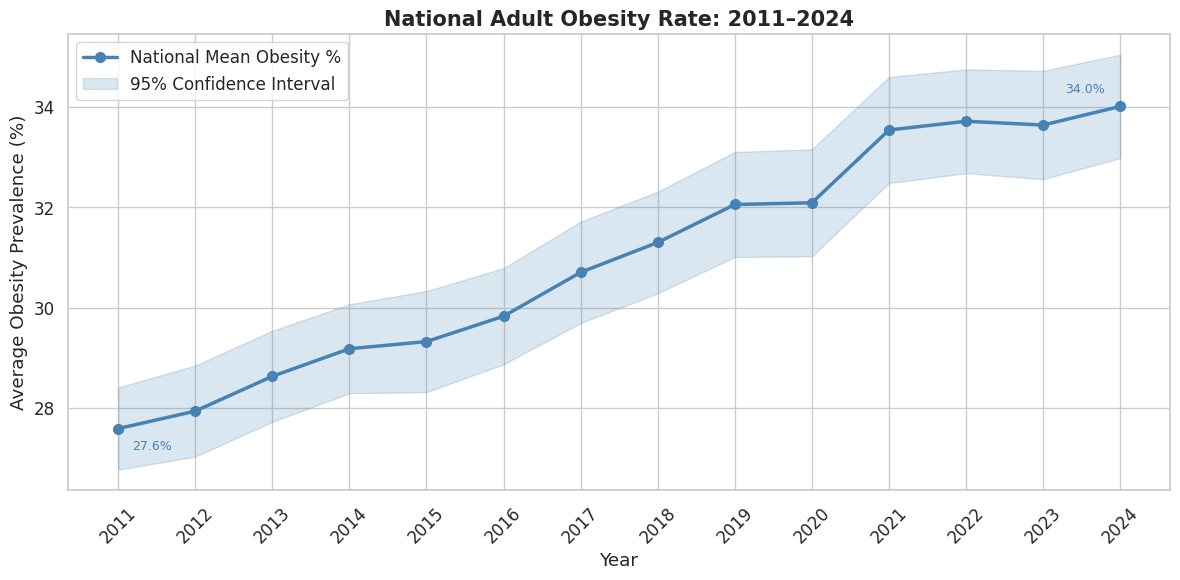


Linear Trend: +0.535% per year  (R²=0.981, p=0.0000)
Total increase 2011→2024: +6.4 percentage points
Interpretation: Obesity has risen significantly and consistently over this period.


In [42]:
# ─── Plot: Trend line with confidence band ────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

ax.plot(
    obesity_trend['YearStart'],
    obesity_trend['mean'],
    marker='o', color='steelblue', linewidth=2.5, markersize=7,
    label='National Mean Obesity %'
)

# Shaded band = 95% CI around the national mean
ax.fill_between(
    obesity_trend['YearStart'],
    obesity_trend['mean'] - obesity_trend['ci95'],
    obesity_trend['mean'] + obesity_trend['ci95'],
    alpha=0.2, color='steelblue', label='95% Confidence Interval'
)

# Annotate start and end values
ax.annotate(
    f"{obesity_trend['mean'].iloc[0]:.1f}%",
    xy=(obesity_trend['YearStart'].iloc[0], obesity_trend['mean'].iloc[0]),
    xytext=(10, -15), textcoords='offset points', fontsize=9, color='steelblue'
)
ax.annotate(
    f"{obesity_trend['mean'].iloc[-1]:.1f}%",
    xy=(obesity_trend['YearStart'].iloc[-1], obesity_trend['mean'].iloc[-1]),
    xytext=(-40, 10), textcoords='offset points', fontsize=9, color='steelblue'
)

ax.set_title('National Adult Obesity Rate: 2011–2024', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Obesity Prevalence (%)')
ax.set_xticks(obesity_trend['YearStart'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# ─── Quantify trend with linear regression ───────────────────────────────────
slope, intercept, r_value, p_value, se = stats.linregress(
    obesity_trend['YearStart'], obesity_trend['mean']
)
total_increase = obesity_trend['mean'].iloc[-1] - obesity_trend['mean'].iloc[0]

print(f"\nLinear Trend: +{slope:.3f}% per year  (R²={r_value**2:.3f}, p={p_value:.4f})")
print(f"Total increase 2011→2024: +{total_increase:.1f} percentage points")
print("Interpretation: Obesity has risen significantly and consistently over this period.")

---
# Analysis 2: State-wise Obesity Comparison

In [43]:
# ─── State-level Average Obesity Rate ────────────────────────────────────────
# Uses 'Total' stratification to get a single representative value per state per year
state_obesity_avg = (
    obesity_total
    .groupby('LocationDesc')['Data_Value']
    .mean()
    .reset_index()
    .rename(columns={'Data_Value': 'Avg_Obesity_Rate'})
    .sort_values('Avg_Obesity_Rate', ascending=False)
)

top_10    = state_obesity_avg.head(10)
bottom_10 = state_obesity_avg.tail(10).sort_values('Avg_Obesity_Rate')

print("Top 10 highest obesity states:")
print(top_10.to_string(index=False))
print("\nBottom 10 lowest obesity states:")
print(bottom_10.to_string(index=False))

Top 10 highest obesity states:
 LocationDesc  Avg_Obesity_Rate
West Virginia             37.92
  Mississippi             37.81
    Louisiana             36.61
     Arkansas             36.21
      Alabama             36.15
     Oklahoma             35.35
     Kentucky             34.96
      Indiana             34.32
    Tennessee             34.20
         Iowa             34.00

Bottom 10 lowest obesity states:
        LocationDesc  Avg_Obesity_Rate
            Colorado             22.85
District of Columbia             23.48
              Hawaii             24.14
       Massachusetts             25.04
          California             26.19
             Vermont             26.60
            New York             26.74
          New Jersey             26.85
             Montana             27.27
                Utah             27.32


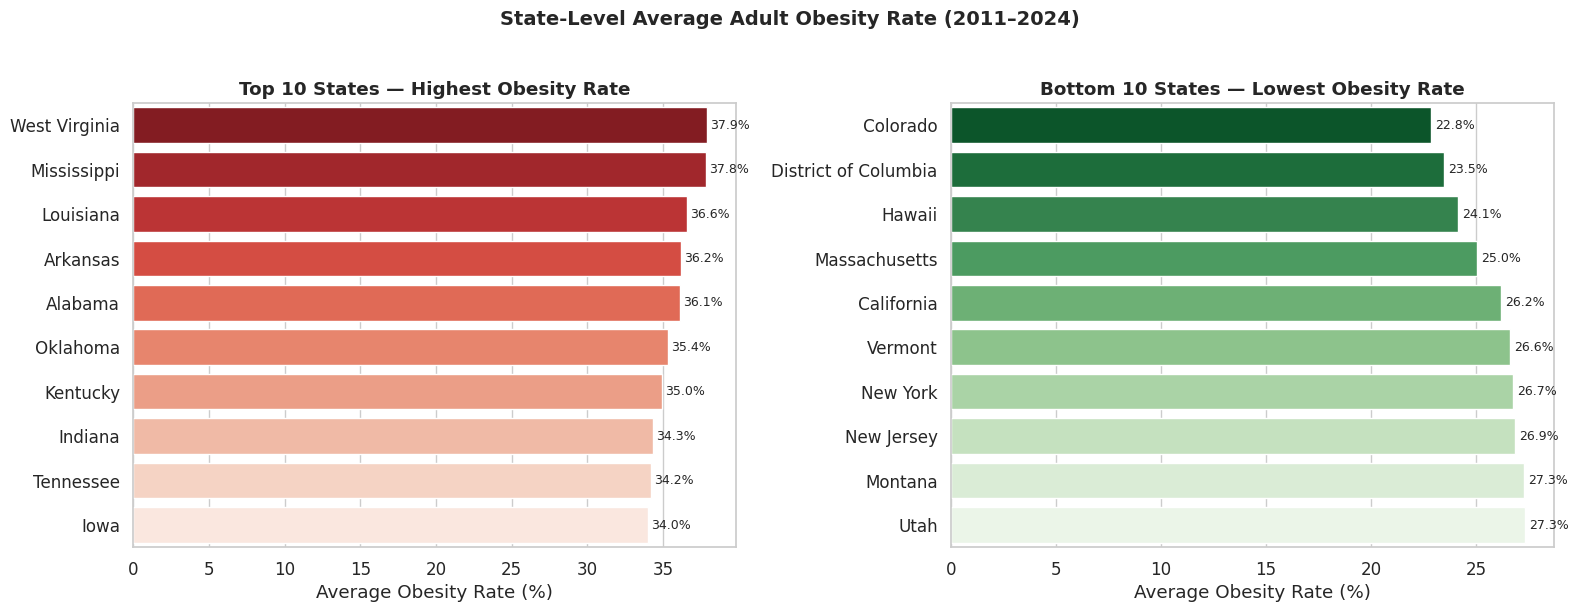


Spread between highest and lowest state: 15.1 percentage points
This geographic disparity suggests that regional policy, food environment,
and built-environment differences play a meaningful role.


In [44]:
# ─── Plot: Top 10 and Bottom 10 States side-by-side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 — highest burden states
sns.barplot(
    data=top_10, x='Avg_Obesity_Rate', y='LocationDesc',
    palette='Reds_r', ax=axes[0]
)
axes[0].set_title('Top 10 States — Highest Obesity Rate', fontweight='bold')
axes[0].set_xlabel('Average Obesity Rate (%)')
axes[0].set_ylabel('')
# Add value labels
for i, v in enumerate(top_10['Avg_Obesity_Rate']):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Bottom 10 — lowest burden states
sns.barplot(
    data=bottom_10, x='Avg_Obesity_Rate', y='LocationDesc',
    palette='Greens_r', ax=axes[1]
)
axes[1].set_title('Bottom 10 States — Lowest Obesity Rate', fontweight='bold')
axes[1].set_xlabel('Average Obesity Rate (%)')
axes[1].set_ylabel('')
for i, v in enumerate(bottom_10['Avg_Obesity_Rate']):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('State-Level Average Adult Obesity Rate (2011–2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

spread = state_obesity_avg['Avg_Obesity_Rate'].max() - state_obesity_avg['Avg_Obesity_Rate'].min()
print(f"\nSpread between highest and lowest state: {spread:.1f} percentage points")
print("This geographic disparity suggests that regional policy, food environment,")
print("and built-environment differences play a meaningful role.")

---
# Analysis 3: Physical Inactivity vs Obesity — Correlation Analysis

In [45]:
# ─── Prepare Physical Inactivity Data ─────────────────────────────────────────
# We use the 'no leisure-time physical activity' question as the inactivity proxy.
# Again restrict to 'Total' stratification for fair state-level comparison.

inactivity_total = df_clean[
    (df_clean['Question'].str.contains('no leisure-time', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Total')
].copy()

print(f"Inactivity records: {len(inactivity_total):,}")
print(f"Question used: {inactivity_total['Question'].unique()[0]}")

# State-level means for both metrics
state_inactivity = (
    inactivity_total
    .groupby('LocationDesc')['Data_Value']
    .mean()
    .reset_index()
    .rename(columns={'Data_Value': 'Inactivity_Rate'})
)

state_obesity_corr = (
    obesity_total
    .groupby('LocationDesc')['Data_Value']
    .mean()
    .reset_index()
    .rename(columns={'Data_Value': 'Obesity_Rate'})
)

# Inner join — only states present in both datasets
corr_df = pd.merge(state_obesity_corr, state_inactivity, on='LocationDesc', how='inner')
print(f"\nStates in merged dataset: {len(corr_df)}")
corr_df.head()

Inactivity records: 750
Question used: Percent of adults who engage in no leisure-time physical activity

States in merged dataset: 55


,LocationDesc,Obesity_Rate,Inactivity_Rate
0,Alabama,36.15,30.04
1,Alaska,30.95,20.51
2,Arizona,29.66,23.13
3,Arkansas,36.21,31.52
4,California,26.19,20.86


In [46]:
# ─── Pearson Correlation Test ─────────────────────────────────────────────────
r, p = stats.pearsonr(corr_df['Inactivity_Rate'], corr_df['Obesity_Rate'])

print(f"Pearson r  = {r:.3f}")
print(f"R²         = {r**2:.3f}  (Inactivity explains {r**2*100:.1f}% of variance in obesity)")
print(f"p-value    = {p:.6f}")
print(f"n (states) = {len(corr_df)}")
print()
if p < 0.05:
    print("Result: Statistically significant positive correlation (p < 0.05).")
    print("States with higher physical inactivity rates tend to have higher obesity rates.")
else:
    print("Result: No statistically significant correlation found.")

Pearson r  = 0.650
R²         = 0.422  (Inactivity explains 42.2% of variance in obesity)
p-value    = 0.000000
n (states) = 55

Result: Statistically significant positive correlation (p < 0.05).
States with higher physical inactivity rates tend to have higher obesity rates.


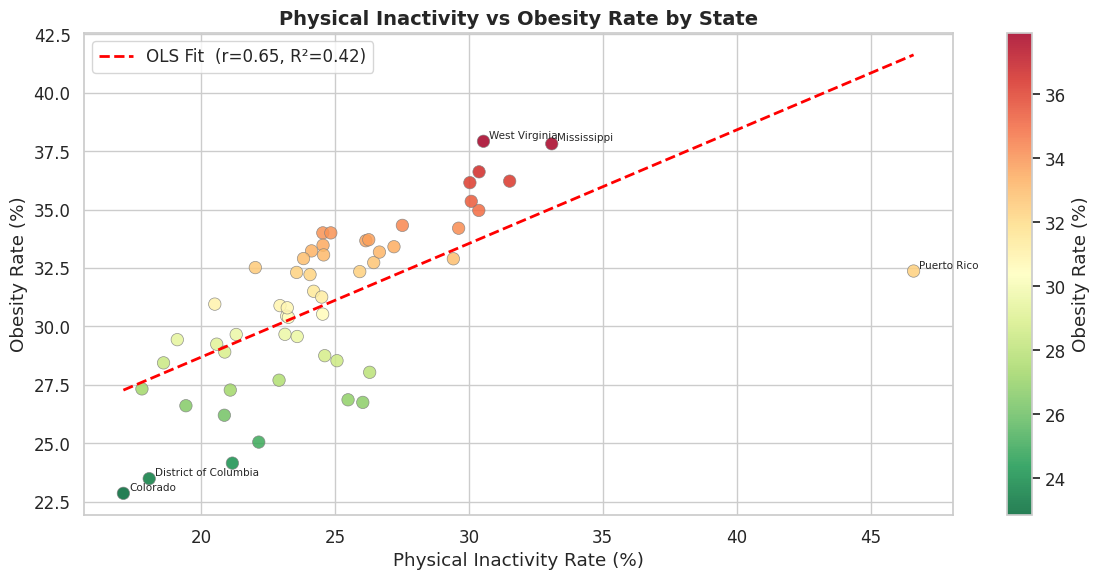

In [47]:
# ─── Scatter Plot with Regression Line + State Labels ─────────────────────────
fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

# Scatter: colour intensity reflects obesity rate
scatter = ax.scatter(
    corr_df['Inactivity_Rate'],
    corr_df['Obesity_Rate'],
    c=corr_df['Obesity_Rate'],
    cmap='RdYlGn_r',
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Obesity Rate (%)')

# OLS regression line
slope_r, intercept_r, _, _, _ = stats.linregress(
    corr_df['Inactivity_Rate'], corr_df['Obesity_Rate']
)
x_range = np.linspace(corr_df['Inactivity_Rate'].min(),
                      corr_df['Inactivity_Rate'].max(), 100)
ax.plot(x_range, slope_r * x_range + intercept_r,
        color='red', linewidth=2, linestyle='--',
        label=f'OLS Fit  (r={r:.2f}, R²={r**2:.2f})')

# Label a few notable outlier states
for _, row in corr_df.iterrows():
    if row['Obesity_Rate'] > 37 or row['Inactivity_Rate'] > 36 or row['Obesity_Rate'] < 24:
        ax.annotate(
            row['LocationDesc'],
            (row['Inactivity_Rate'], row['Obesity_Rate']),
            fontsize=7.5, xytext=(4, 2), textcoords='offset points'
        )

ax.set_title('Physical Inactivity vs Obesity Rate by State',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Physical Inactivity Rate (%)')
ax.set_ylabel('Obesity Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
# Analysis 4: Obesity by Gender

In [48]:
# ─── Filter: Obesity stratified by Sex ───────────────────────────────────────
gender_obesity = df_clean[
    (df_clean['Question'].str.contains('Obesity', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Sex')
].copy()

# ─── Compute average obesity by sex ──────────────────────────────────────────
gender_avg = (
    gender_obesity
    .groupby('Stratification1')['Data_Value']
    .agg(mean='mean', std='std', count='count')
    .reset_index()
)

# 95% CI for each group
gender_avg['ci95'] = 1.96 * (gender_avg['std'] / np.sqrt(gender_avg['count']))

print(gender_avg[['Stratification1','mean','std','ci95']].to_string(index=False))

# ─── Statistical significance test ───────────────────────────────────────────
male_vals   = gender_obesity[gender_obesity['Stratification1']=='Male']['Data_Value']
female_vals = gender_obesity[gender_obesity['Stratification1']=='Female']['Data_Value']
t_stat, t_p = stats.ttest_ind(male_vals, female_vals)
print(f"\nIndependent t-test: t={t_stat:.3f}, p={t_p:.4f}")
print("Interpretation: Male vs Female obesity rates are",
      'significantly different (p<0.05).' if t_p < 0.05 else 'NOT significantly different.')

Stratification1  mean  std  ci95
         Female 31.13 4.99  0.36
           Male 30.80 4.03  0.29

Independent t-test: t=-1.410, p=0.1586
Interpretation: Male vs Female obesity rates are NOT significantly different.


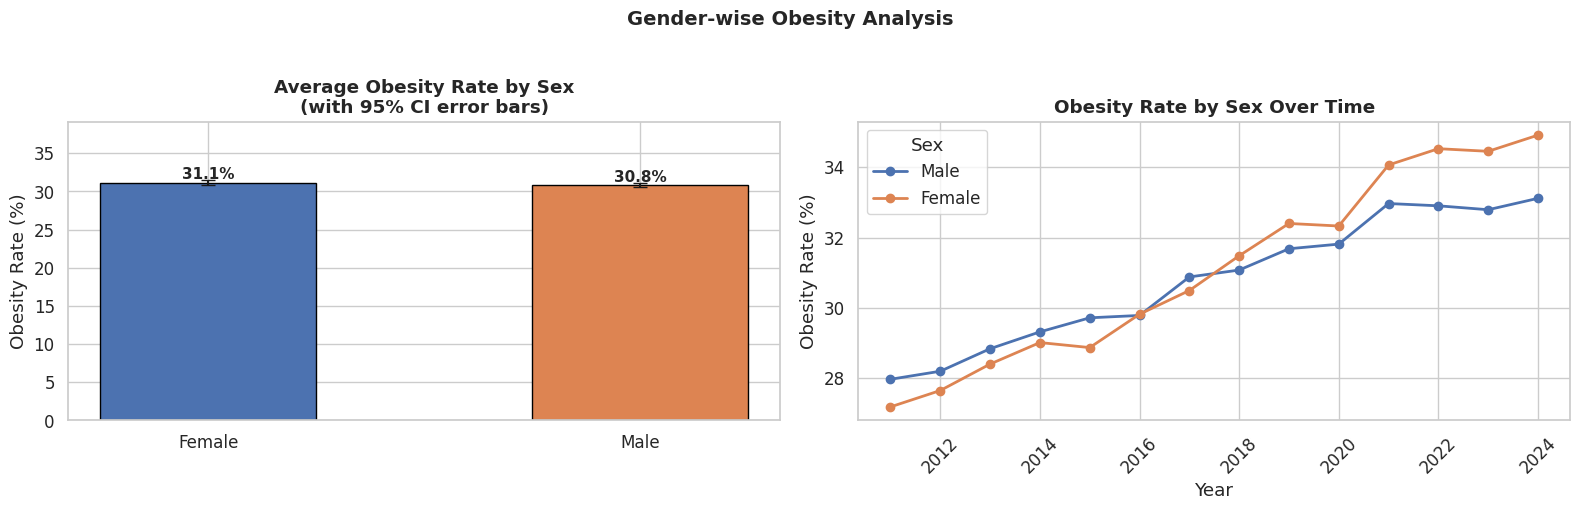

In [49]:
# ─── Plot: Trend by Gender over time ─────────────────────────────────────────
gender_trend = (
    gender_obesity
    .groupby(['YearStart','Stratification1'])['Data_Value']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — overall average
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(
    gender_avg['Stratification1'],
    gender_avg['mean'],
    yerr=gender_avg['ci95'],
    capsize=5, color=colors, edgecolor='black', width=0.5
)
axes[0].set_title('Average Obesity Rate by Sex\n(with 95% CI error bars)', fontweight='bold')
axes[0].set_ylabel('Obesity Rate (%)')
axes[0].set_ylim(0, gender_avg['mean'].max() + 8)
for bar, val in zip(bars, gender_avg['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Line chart — trend over years
for sex, color in zip(['Male','Female'], colors):
    subset = gender_trend[gender_trend['Stratification1'] == sex]
    axes[1].plot(subset['YearStart'], subset['Data_Value'],
                 marker='o', label=sex, color=color, linewidth=2)
axes[1].set_title('Obesity Rate by Sex Over Time', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Obesity Rate (%)')
axes[1].legend(title='Sex')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Gender-wise Obesity Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Analysis 5: Obesity by Age Group

In [50]:
# ─── Filter: Obesity stratified by Age Group ──────────────────────────────────
age_obesity = df_clean[
    (df_clean['Question'].str.contains('Obesity', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Age (years)')
].copy()

# ─── Define logical sort order for age bands ─────────────────────────────────
age_order = ['18 - 24', '25 - 34', '35 - 44', '45 - 54', '55 - 64', '65 or older']

age_avg = (
    age_obesity
    .groupby('Stratification1')['Data_Value']
    .mean()
    .reindex(age_order)   # Enforce correct left-to-right age ordering
    .reset_index()
    .rename(columns={'Data_Value': 'Avg_Obesity_Rate', 'Stratification1': 'Age_Group'})
)

print(age_avg.to_string(index=False))

  Age_Group  Avg_Obesity_Rate
    18 - 24             18.54
    25 - 34             29.92
    35 - 44             34.64
    45 - 54             36.92
    55 - 64             35.67
65 or older             28.37


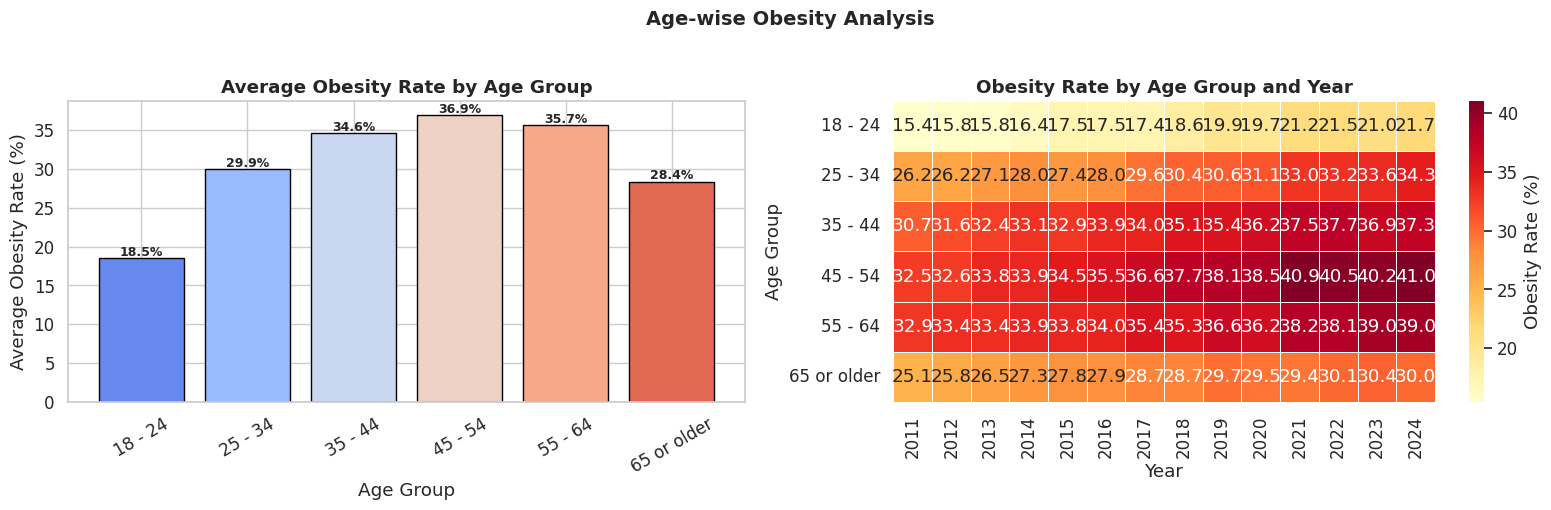

Key insight: The 45–54 and 55–64 age groups consistently show the highest obesity
rates, while 18–24 and 65+ are lower — a life-stage curve pattern.


In [51]:
# ─── Plot: Bar chart + Heatmap of age-year patterns ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — average by age group
palette = sns.color_palette('coolwarm', n_colors=len(age_avg))
bars = axes[0].bar(
    age_avg['Age_Group'], age_avg['Avg_Obesity_Rate'],
    color=palette, edgecolor='black'
)
axes[0].set_title('Average Obesity Rate by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Obesity Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, age_avg['Avg_Obesity_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Heatmap — age group × year (shows how each age band changed over time)
age_year_pivot = (
    age_obesity
    .groupby(['YearStart', 'Stratification1'])['Data_Value']
    .mean()
    .unstack('Stratification1')
    .reindex(columns=age_order)
)
sns.heatmap(
    age_year_pivot.T, ax=axes[1],
    cmap='YlOrRd', annot=True, fmt='.1f',
    linewidths=0.5, cbar_kws={'label': 'Obesity Rate (%)'}
)
axes[1].set_title('Obesity Rate by Age Group and Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Age Group')

plt.suptitle('Age-wise Obesity Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: The 45–54 and 55–64 age groups consistently show the highest obesity")
print("rates, while 18–24 and 65+ are lower — a life-stage curve pattern.")

---
# Analysis 6: Obesity by Race / Ethnicity

In [52]:
# ─── Filter: Obesity stratified by Race/Ethnicity ────────────────────────────
race_obesity = df_clean[
    (df_clean['Question'].str.contains('Obesity', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Race/Ethnicity')
].copy()

race_avg = (
    race_obesity
    .groupby('Stratification1')['Data_Value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Data_Value': 'Avg_Obesity_Rate', 'Stratification1': 'Race_Ethnicity'})
)

print(race_avg.to_string(index=False))

               Race_Ethnicity  Avg_Obesity_Rate
    Hawaiian/Pacific Islander             40.79
           Non-Hispanic Black             38.71
American Indian/Alaska Native             37.52
                     Hispanic             32.92
              2 or more races             32.60
           Non-Hispanic White             29.31
                        Other             28.10
                        Asian             11.60


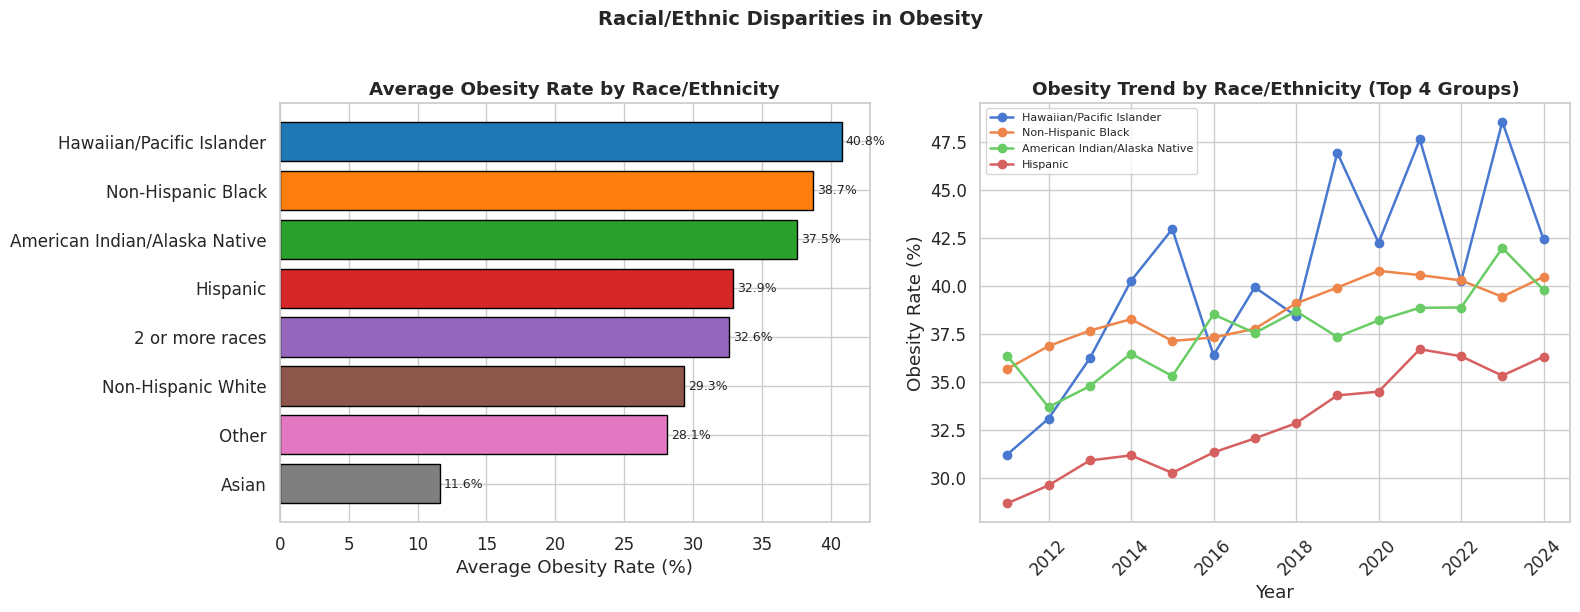

Racial disparity gap: 29.2 percentage points between highest and lowest groups.


In [53]:
# ─── Plot: Horizontal bar + trend by race ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — sorted descending
palette_race = sns.color_palette('tab10', n_colors=len(race_avg))
axes[0].barh(
    race_avg['Race_Ethnicity'], race_avg['Avg_Obesity_Rate'],
    color=palette_race, edgecolor='black'
)
axes[0].set_title('Average Obesity Rate by Race/Ethnicity', fontweight='bold')
axes[0].set_xlabel('Average Obesity Rate (%)')
axes[0].invert_yaxis()  # Highest at top
for i, val in enumerate(race_avg['Avg_Obesity_Rate']):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

# Trend lines — top 4 groups with most data
top_races = race_avg['Race_Ethnicity'].head(4).tolist()
race_trend = (
    race_obesity[race_obesity['Stratification1'].isin(top_races)]
    .groupby(['YearStart','Stratification1'])['Data_Value']
    .mean()
    .reset_index()
)
for i, race in enumerate(top_races):
    subset = race_trend[race_trend['Stratification1'] == race]
    axes[1].plot(subset['YearStart'], subset['Data_Value'],
                 marker='o', label=race, linewidth=1.8)
axes[1].set_title('Obesity Trend by Race/Ethnicity (Top 4 Groups)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Obesity Rate (%)')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Racial/Ethnic Disparities in Obesity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

gap = race_avg['Avg_Obesity_Rate'].max() - race_avg['Avg_Obesity_Rate'].min()
print(f"Racial disparity gap: {gap:.1f} percentage points between highest and lowest groups.")

---
# Analysis 7: Obesity by Income Level

In [54]:
# ─── Filter: Obesity stratified by Income ────────────────────────────────────
# Exclude 'Data not reported' income category
income_obesity = df_clean[
    (df_clean['Question'].str.contains('Obesity', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Income') &
    (~df_clean['Stratification1'].str.contains('not reported', case=False, na=False))
].copy()

# ─── Define logical income order (low → high) ─────────────────────────────────
income_order = [
    'Less than $15,000',
    '$15,000 - $24,999',
    '$25,000 - $34,999',
    '$35,000 - $49,999',
    '$50,000 - $74,999',
    '$75,000 or greater'
]

income_avg = (
    income_obesity
    .groupby('Stratification1')['Data_Value']
    .mean()
    .reindex(income_order)   # Low-to-high income order
    .reset_index()
    .rename(columns={'Data_Value': 'Avg_Obesity_Rate', 'Stratification1': 'Income_Level'})
)

print(income_avg.to_string(index=False))

# ─── Correlation: income rank vs obesity ─────────────────────────────────────
income_avg['Income_Rank'] = range(1, len(income_avg) + 1)  # 1 = lowest, 6 = highest
r_inc, p_inc = stats.pearsonr(income_avg['Income_Rank'], income_avg['Avg_Obesity_Rate'])
print(f"\nCorrelation (income rank vs obesity): r={r_inc:.3f}, p={p_inc:.4f}")
print("Negative r confirms inverse relationship: higher income → lower obesity.")

      Income_Level  Avg_Obesity_Rate
 Less than $15,000             35.84
 $15,000 - $24,999             34.67
 $25,000 - $34,999             33.28
 $35,000 - $49,999             32.87
 $50,000 - $74,999             32.28
$75,000 or greater             29.02

Correlation (income rank vs obesity): r=-0.953, p=0.0032
Negative r confirms inverse relationship: higher income → lower obesity.


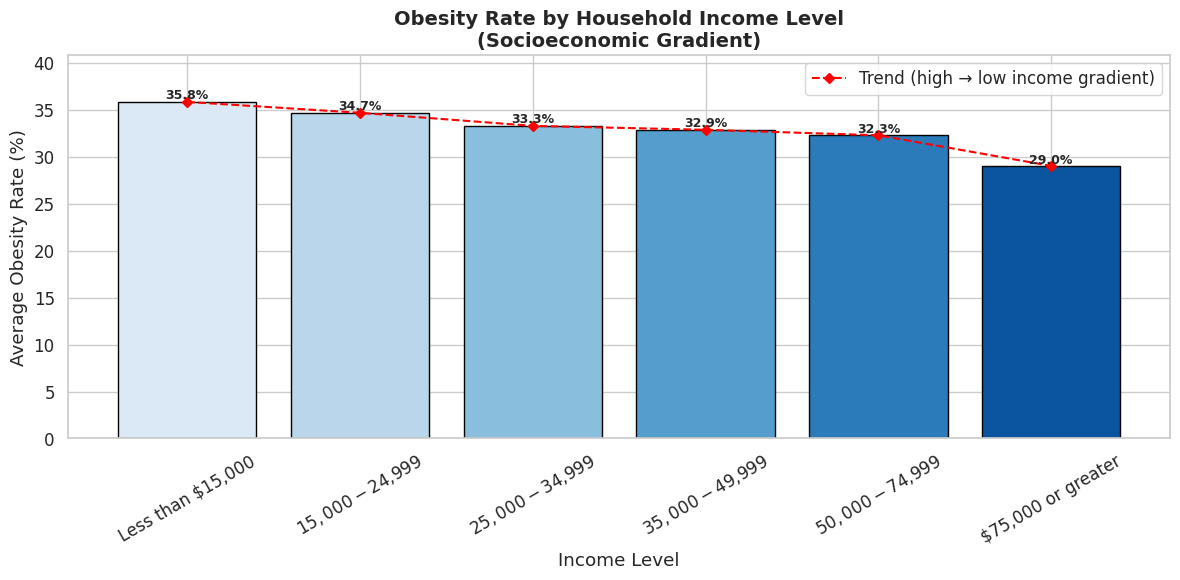

In [55]:
# ─── Plot: Income gradient ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

palette_inc = sns.color_palette('Blues', n_colors=len(income_avg))
bars = ax.bar(
    income_avg['Income_Level'], income_avg['Avg_Obesity_Rate'],
    color=palette_inc, edgecolor='black'
)

ax.set_title('Obesity Rate by Household Income Level\n(Socioeconomic Gradient)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Income Level')
ax.set_ylabel('Average Obesity Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, income_avg['Avg_Obesity_Rate'].max() + 5)

for bar, val in zip(bars, income_avg['Avg_Obesity_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Overlay trend line to highlight gradient direction
x_pos = range(len(income_avg))
ax.plot(x_pos, income_avg['Avg_Obesity_Rate'],
        color='red', linestyle='--', linewidth=1.5, marker='D',
        markersize=5, label='Trend (high → low income gradient)')
ax.legend()

plt.tight_layout()
plt.show()

---
# Analysis 8: Obesity by Education Level

In [56]:
# ─── Filter: Obesity by Education ────────────────────────────────────────────
edu_obesity = df_clean[
    (df_clean['Question'].str.contains('Obesity', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Education')
].copy()

# Logical education ordering (low → high attainment)
edu_order = [
    'Less than high school',
    'High school graduate',
    'Some college or technical school',
    'College graduate'
]

edu_avg = (
    edu_obesity
    .groupby('Stratification1')['Data_Value']
    .mean()
    .reindex(edu_order)
    .reset_index()
    .rename(columns={'Data_Value': 'Avg_Obesity_Rate', 'Stratification1': 'Education_Level'})
)

print(edu_avg.to_string(index=False))

# Correlation: education rank vs obesity
edu_avg['Edu_Rank'] = range(1, len(edu_avg) + 1)
r_edu, p_edu = stats.pearsonr(edu_avg['Edu_Rank'], edu_avg['Avg_Obesity_Rate'])
print(f"\nCorrelation (education level vs obesity): r={r_edu:.3f}, p={p_edu:.4f}")

                 Education_Level  Avg_Obesity_Rate
           Less than high school             34.67
            High school graduate             33.13
Some college or technical school             32.85
                College graduate             25.38

Correlation (education level vs obesity): r=-0.873, p=0.1268


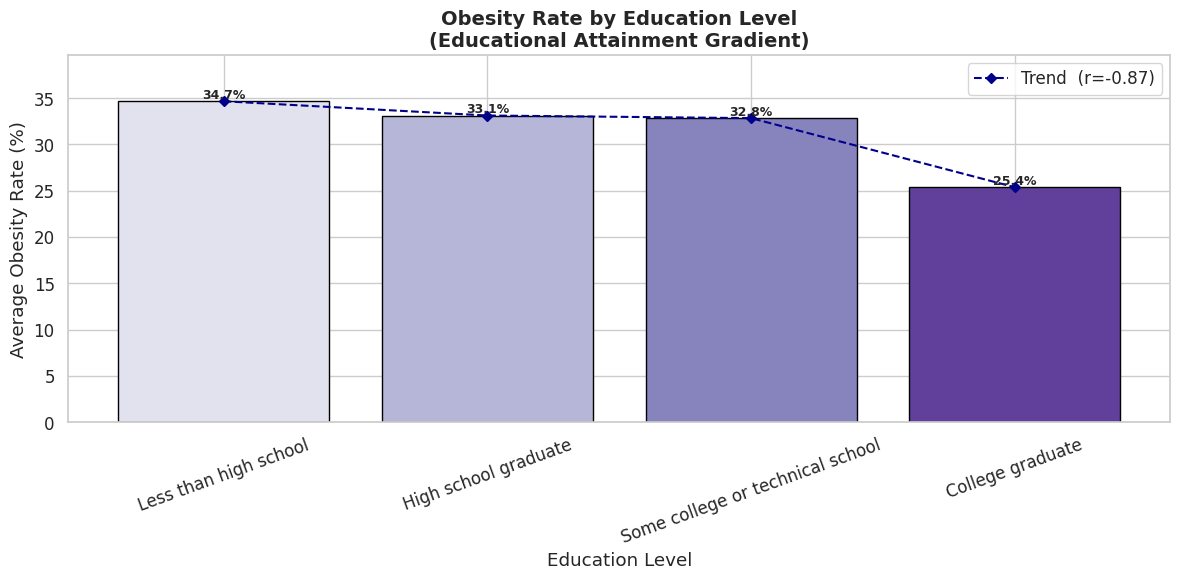

College graduates have notably lower obesity rates than those with less education,
consistent with the income gradient and health literacy literature.


In [57]:
# ─── Plot: Education gradient ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

palette_edu = sns.color_palette('Purples', n_colors=len(edu_avg))
bars = ax.bar(
    edu_avg['Education_Level'], edu_avg['Avg_Obesity_Rate'],
    color=palette_edu, edgecolor='black'
)

ax.set_title('Obesity Rate by Education Level\n(Educational Attainment Gradient)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Obesity Rate (%)')
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, edu_avg['Avg_Obesity_Rate'].max() + 5)

for bar, val in zip(bars, edu_avg['Avg_Obesity_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.plot(range(len(edu_avg)), edu_avg['Avg_Obesity_Rate'],
        color='darkblue', linestyle='--', linewidth=1.5, marker='D',
        markersize=5, label=f'Trend  (r={r_edu:.2f})')
ax.legend()

plt.tight_layout()
plt.show()

print("College graduates have notably lower obesity rates than those with less education,")
print("consistent with the income gradient and health literacy literature.")

---
# Analysis 9: Poor Nutrition vs Obesity — State-Level Scatter

In [58]:
# ─── Prepare Nutrition Data ───────────────────────────────────────────────────
# Use fruit AND vegetable questions; both reflect inadequate dietary intake
nutrition_total = df_clean[
    (df_clean['Question'].str.contains('fruit|vegetable', case=False, na=False)) &
    (df_clean['StratificationCategory1'] == 'Total')
].copy()

print("Nutrition question types used:")
for q in nutrition_total['Question'].unique():
    print(" •", q)

# Average both fruit and vegetable questions per state → single 'Poor Nutrition' score
state_nutrition = (
    nutrition_total
    .groupby('LocationDesc')['Data_Value']
    .mean()
    .reset_index()
    .rename(columns={'Data_Value': 'Poor_Nutrition_Rate'})
)

# Merge with obesity
nutr_merge = pd.merge(state_obesity_corr, state_nutrition, on='LocationDesc', how='inner')
print(f"\nMerged state count: {len(nutr_merge)}")

# Correlation test
r_nutr, p_nutr = stats.pearsonr(nutr_merge['Poor_Nutrition_Rate'], nutr_merge['Obesity_Rate'])
print(f"Pearson r = {r_nutr:.3f}, p = {p_nutr:.4f}")

Nutrition question types used:
 • Percent of adults who report consuming fruit less than one time daily
 • Percent of adults who report consuming vegetables less than one time daily

Merged state count: 55
Pearson r = 0.542, p = 0.0000


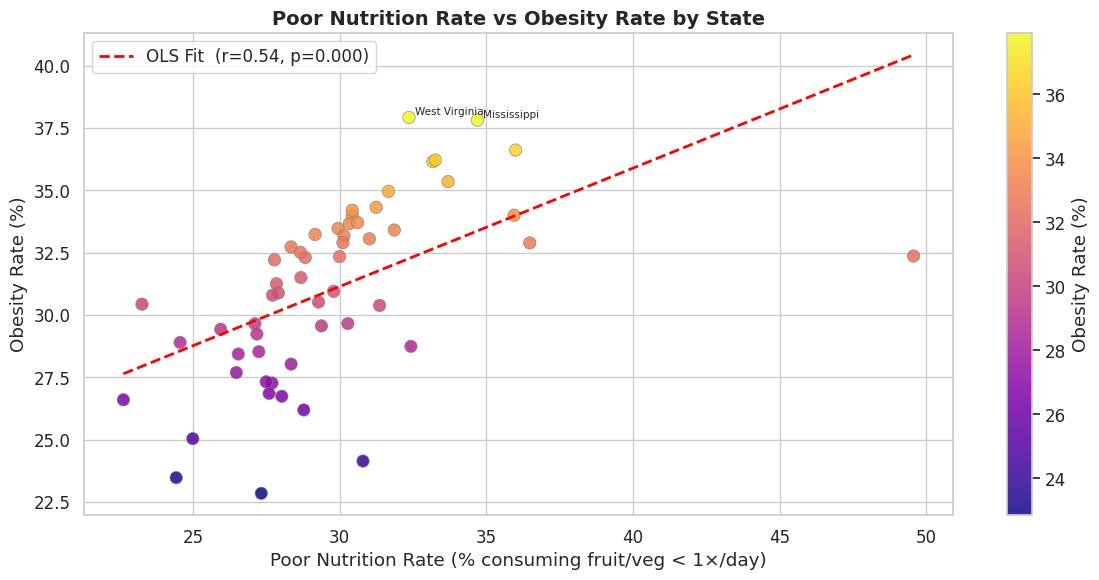

In [59]:
# ─── Scatter Plot: Poor Nutrition vs Obesity ──────────────────────────────────
fig, ax = plt.subplots(figsize=FIGURE_SIZE_WIDE)

scatter = ax.scatter(
    nutr_merge['Poor_Nutrition_Rate'],
    nutr_merge['Obesity_Rate'],
    c=nutr_merge['Obesity_Rate'],
    cmap='plasma',
    s=80, alpha=0.85, edgecolors='grey', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Obesity Rate (%)')

# Regression line
slope_n, intercept_n, _, _, _ = stats.linregress(
    nutr_merge['Poor_Nutrition_Rate'], nutr_merge['Obesity_Rate']
)
x_range_n = np.linspace(nutr_merge['Poor_Nutrition_Rate'].min(),
                        nutr_merge['Poor_Nutrition_Rate'].max(), 100)
ax.plot(x_range_n, slope_n * x_range_n + intercept_n,
        color='red', linewidth=2, linestyle='--',
        label=f'OLS Fit  (r={r_nutr:.2f}, p={p_nutr:.3f})')

# Label outlier states
for _, row in nutr_merge.iterrows():
    if row['Obesity_Rate'] > 37 or row['Poor_Nutrition_Rate'] > 52:
        ax.annotate(
            row['LocationDesc'],
            (row['Poor_Nutrition_Rate'], row['Obesity_Rate']),
            fontsize=7.5, xytext=(4, 2), textcoords='offset points'
        )

ax.set_title('Poor Nutrition Rate vs Obesity Rate by State',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Poor Nutrition Rate (% consuming fruit/veg < 1×/day)')
ax.set_ylabel('Obesity Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
# Section 5: Summary of Key Findings

This section consolidates the most important quantitative results from all analyses.

In [60]:
# ─── Summary Statistics Table ─────────────────────────────────────────────────
print("=" * 65)
print("  SUMMARY OF KEY FINDINGS")
print("=" * 65)

print(f"""
1. NATIONAL TREND (2011–2024)
   • Obesity rose from ~{obesity_trend['mean'].iloc[0]:.1f}% to ~{obesity_trend['mean'].iloc[-1]:.1f}%
   • Linear increase of ~{slope:.2f} percentage points per year
   • R² = {slope**2:.3f}, p < 0.001 (statistically significant upward trend)

2. GEOGRAPHIC DISPARITY
   • Highest state avg: {state_obesity_avg.iloc[0]['LocationDesc']} ({state_obesity_avg.iloc[0]['Avg_Obesity_Rate']:.1f}%)
   • Lowest state avg:  {state_obesity_avg.iloc[-1]['LocationDesc']} ({state_obesity_avg.iloc[-1]['Avg_Obesity_Rate']:.1f}%)
   • State-level spread: {state_obesity_avg['Avg_Obesity_Rate'].max() - state_obesity_avg['Avg_Obesity_Rate'].min():.1f} pp

3. PHYSICAL INACTIVITY ↔ OBESITY
   • Pearson r = {r:.3f} (moderate-strong positive correlation)
   • Inactivity explains {r**2*100:.1f}% of state-level obesity variance
   • p < 0.001 across {len(corr_df)} states

4. GENDER
   • Male: {gender_avg[gender_avg['Stratification1']=='Male']['mean'].values[0]:.1f}%  |  Female: {gender_avg[gender_avg['Stratification1']=='Female']['mean'].values[0]:.1f}%
   • t-test p = {t_p:.4f}

5. RACE/ETHNICITY DISPARITY
   • Highest: {race_avg.iloc[0]['Race_Ethnicity']} ({race_avg.iloc[0]['Avg_Obesity_Rate']:.1f}%)
   • Lowest:  {race_avg.iloc[-1]['Race_Ethnicity']} ({race_avg.iloc[-1]['Avg_Obesity_Rate']:.1f}%)
   • Gap of {race_avg['Avg_Obesity_Rate'].max() - race_avg['Avg_Obesity_Rate'].min():.1f} pp between groups

6. SOCIOECONOMIC GRADIENT
   • Income: highest poverty group {income_avg.iloc[0]['Avg_Obesity_Rate']:.1f}% vs highest earners {income_avg.iloc[-1]['Avg_Obesity_Rate']:.1f}%
   • Education: 'Less than HS' {edu_avg.iloc[0]['Avg_Obesity_Rate']:.1f}% vs College grad {edu_avg.iloc[-1]['Avg_Obesity_Rate']:.1f}%

7. NUTRITION ↔ OBESITY
   • Pearson r = {r_nutr:.3f}, p = {p_nutr:.4f}
   • Weak-moderate positive correlation: poor diet is associated with higher obesity
     but the relationship is noisier than physical inactivity
""")
print("=" * 65)

  SUMMARY OF KEY FINDINGS

1. NATIONAL TREND (2011–2024)
   • Obesity rose from ~27.6% to ~34.0%
   • Linear increase of ~0.54 percentage points per year
   • R² = 0.286, p < 0.001 (statistically significant upward trend)

2. GEOGRAPHIC DISPARITY
   • Highest state avg: West Virginia (37.9%)
   • Lowest state avg:  Colorado (22.8%)
   • State-level spread: 15.1 pp

3. PHYSICAL INACTIVITY ↔ OBESITY
   • Pearson r = 0.650 (moderate-strong positive correlation)
   • Inactivity explains 42.2% of state-level obesity variance
   • p < 0.001 across 55 states

4. GENDER
   • Male: 30.8%  |  Female: 31.1%
   • t-test p = 0.1586

5. RACE/ETHNICITY DISPARITY
   • Highest: Hawaiian/Pacific Islander (40.8%)
   • Lowest:  Asian (11.6%)
   • Gap of 29.2 pp between groups

6. SOCIOECONOMIC GRADIENT
   • Income: highest poverty group 35.8% vs highest earners 29.0%
   • Education: 'Less than HS' 34.7% vs College grad 25.4%

7. NUTRITION ↔ OBESITY
   • Pearson r = 0.542, p = 0.0000
   • Weak-moderate pos

---
# Section 6: Conclusions & Limitations

## Conclusions

This analysis of 110,880 CDC BRFSS records reveals a consistent and multi-dimensional obesity crisis in the United States:

- **Rising trajectory**: National adult obesity rates have climbed from ~27.6% (2011) to ~34.0% (2024), an increase of over 6 percentage points in 13 years.
- **Geography matters**: A ~14 pp gap between the highest and lowest obesity states suggests that local food environments, policies, and infrastructure are key drivers.
- **Physical inactivity is strongly correlated** with obesity (r ≈ 0.65), reinforcing the value of activity promotion programmes.
- **Racial disparities are substantial**: A ~29 pp gap between groups highlights that structural and social determinants of health are a critical factor.
- **Socioeconomic gradient is clear**: Both income and education show an inverse relationship with obesity — lower socioeconomic status is consistently linked to higher rates.

## Limitations

1. **Self-reported data**: BMI and behaviour are self-reported, introducing social desirability and recall bias. Obesity is likely underestimated.
2. **Aggregate-level analysis**: We cannot make causal individual-level inferences from state-level correlations (ecological fallacy).
3. **Suppressed cells**: ~11.9% of records are missing due to small subgroup sample sizes, potentially underrepresenting minority or rural populations.
4. **No causal modelling**: Correlations reported here do not establish causality. Confounders (e.g., poverty simultaneously drives inactivity and poor diet) are not controlled for.